# Titanic Pipeline Notebook
**Dataset:** Titanic (binary classification — survived or not)  
**Core Concepts Covered:**
1. Data Exploration (EDA)
2. Data Preprocessing
3. Feature Engineering
4. Model Selection & Training
5. Evaluation Metrics
6. Hyperparameter Tuning

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


---
## SECTION 1 — Data Loading & Exploration (EDA)

In [15]:
# Load Titanic dataset (built into seaborn)
df = sns.load_dataset('titanic')
print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
# Summary statistics
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0])

             count        pct
age            177  19.865320
embarked         2   0.224467
deck           688  77.216611
embark_town      2   0.224467


In [19]:
# Target distribution
print('Survived value counts:')
print(df['survived'].value_counts())
print('\nClass balance (%):')
print(df['survived'].value_counts(normalize=True) * 100)

Survived value counts:
survived
0    549
1    342
Name: count, dtype: int64

Class balance (%):
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


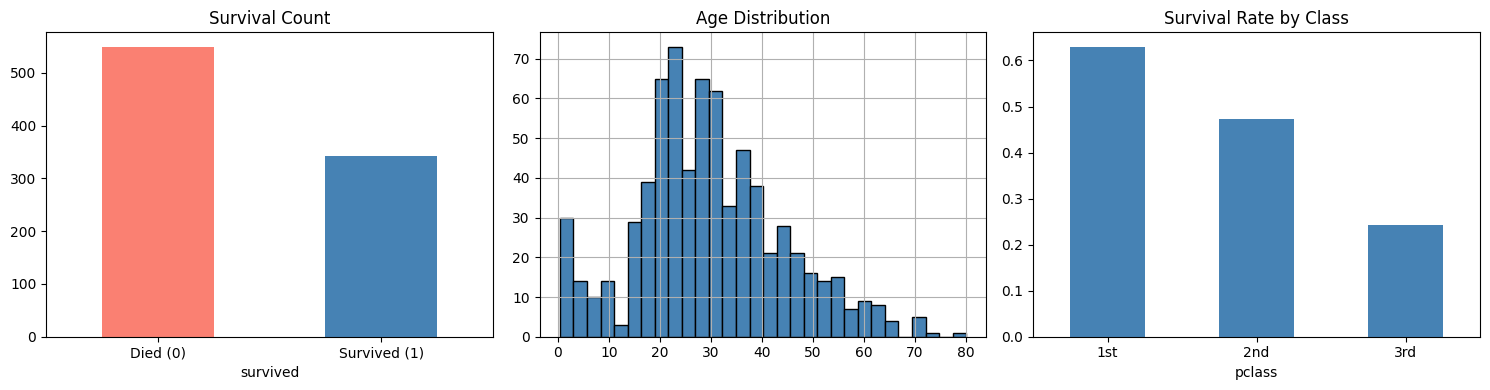

In [20]:
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival count
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)

# Age distribution
df['age'].dropna().hist(bins=30, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Age Distribution')

# Survival by class
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Survival Rate by Class')
axes[2].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

plt.tight_layout()
plt.show()

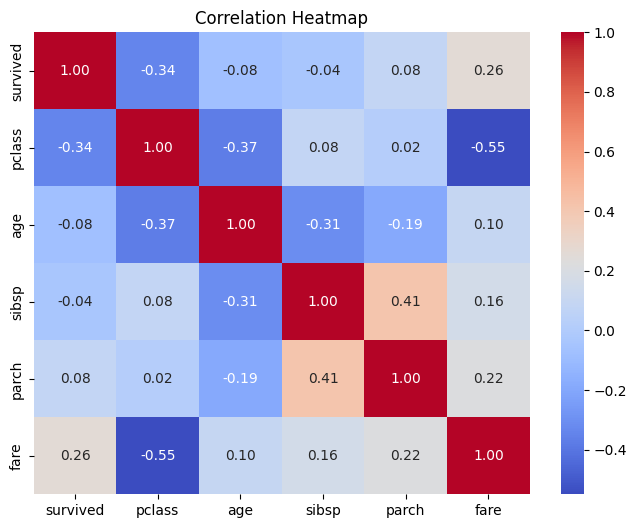

In [21]:
# Correlation heatmap (numeric features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

---
## SECTION 2 — Data Preprocessing
Goal: handle missing values, encode categoricals, drop useless columns.

In [22]:
# Work on a copy
data = df.copy()

# Drop duplicate/redundant columns
# 'alive' = string version of 'survived', 'embark_town' = same as 'embarked'
# 'class' = string version of 'pclass' (already numeric)
# 'who', 'adult_male', 'alone' are derived — keep raw features instead
cols_to_drop = ['alive', 'embark_town', 'who', 'adult_male', 'alone', 'deck', 'class']
data.drop(columns=cols_to_drop, inplace=True)

print('Columns after dropping:', list(data.columns))

Columns after dropping: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [23]:
# --- Handle Missing Values ---

# Age: fill with median (robust to outliers)
data['age'].fillna(data['age'].median(), inplace=True)

# Embarked: fill with mode (most frequent port)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

# Verify
print('Missing values after imputation:')
print(data.isnull().sum())

Missing values after imputation:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [24]:
# --- Encode Categorical Variables ---

# Binary encoding: sex  (male=1, female=0)
data['sex'] = LabelEncoder().fit_transform(data['sex'])  # male->1, female->0

# One-hot encoding: embarked (C, Q, S)
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)

print('Columns after encoding:', list(data.columns))
data.head()

Columns after encoding: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [25]:
# --- Split into Features and Target ---
X = data.drop('survived', axis=1)
y = data['survived']

# Train / Test Split (80/20, stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Train class balance:', y_train.value_counts(normalize=True).to_dict())

Train: (712, 8)  |  Test: (179, 8)
Train class balance: {0: 0.6165730337078652, 1: 0.38342696629213485}


In [26]:
# --- Feature Scaling ---
# Required for k-NN, Logistic Regression, SVM (distance/gradient-based)
# NOT required for tree-based models

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # transform test using train stats

print('Scaling done. Train mean (should be ~0):', X_train_scaled.mean(axis=0).round(2))

Scaling done. Train mean (should be ~0): [-0. -0.  0. -0. -0. -0. -0.  0.]


---
## SECTION 3 — Feature Engineering
Goal: create new informative features from existing ones.

In [27]:
# Re-start from clean data to add engineered features
data_fe = df.copy()
data_fe.drop(columns=['alive', 'embark_town', 'who', 'adult_male', 'alone', 'deck', 'class'], inplace=True)
data_fe['age'].fillna(data_fe['age'].median(), inplace=True)
data_fe['embarked'].fillna(data_fe['embarked'].mode()[0], inplace=True)

# --- New Feature 1: Family Size ---
data_fe['family_size'] = data_fe['sibsp'] + data_fe['parch'] + 1  # include self

# --- New Feature 2: Is Alone ---
data_fe['is_alone'] = (data_fe['family_size'] == 1).astype(int)

# --- New Feature 3: Age Bin (child / adult / senior) ---
data_fe['age_bin'] = pd.cut(
    data_fe['age'],
    bins=[0, 12, 60, 100],
    labels=['child', 'adult', 'senior']
)

# --- New Feature 4: Fare per Person ---
data_fe['fare_per_person'] = data_fe['fare'] / data_fe['family_size']

# Check correlation of new features with target
print('Correlation of new features with survived:')
print(data_fe[['family_size', 'is_alone', 'fare_per_person', 'survived']].corr()['survived'])

Correlation of new features with survived:
family_size        0.016639
is_alone          -0.203367
fare_per_person    0.221600
survived           1.000000
Name: survived, dtype: float64


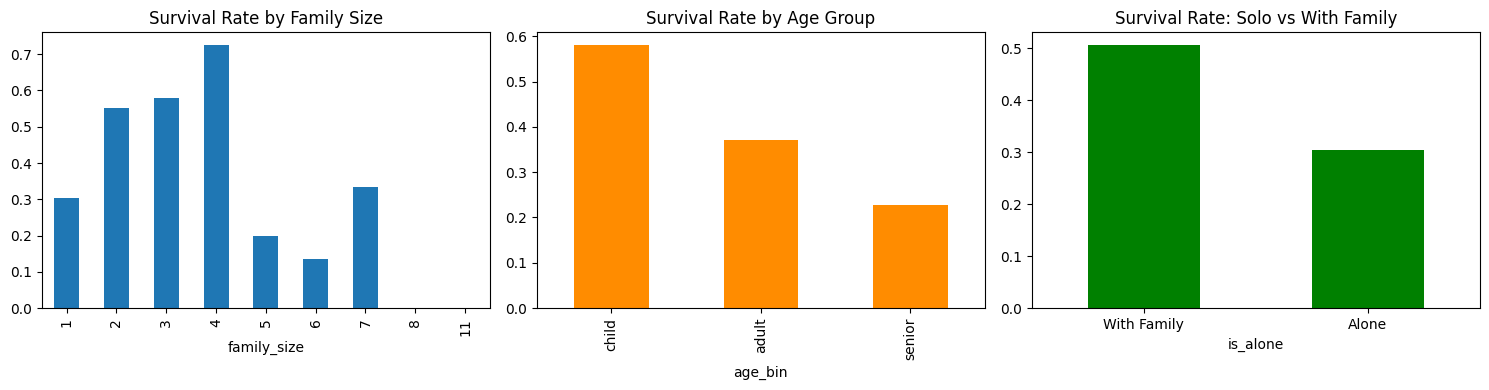

In [28]:
# Visualize impact of engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data_fe.groupby('family_size')['survived'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Survival Rate by Family Size')

data_fe.groupby('age_bin')['survived'].mean().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Survival Rate by Age Group')

data_fe.groupby('is_alone')['survived'].mean().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Survival Rate: Solo vs With Family')
axes[2].set_xticklabels(['With Family', 'Alone'], rotation=0)

plt.tight_layout()
plt.show()

In [29]:
# Encode and build final feature set WITH engineered features
data_fe['sex'] = LabelEncoder().fit_transform(data_fe['sex'])
data_fe = pd.get_dummies(data_fe, columns=['embarked', 'age_bin'], drop_first=True)

X_fe = data_fe.drop('survived', axis=1)
y_fe = data_fe['survived']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe)

print('Feature set with engineering:', list(X_fe.columns))

Feature set with engineering: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'embarked_Q', 'embarked_S', 'age_bin_adult', 'age_bin_senior']


---
## SECTION 4 — Model Selection & Training
We train 5 models and compare them side by side.

In [30]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'k-NN (k=5)':         KNeighborsClassifier(n_neighbors=5),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True),
}

results = {}

for name, model in models.items():
    # Tree models use unscaled data; others use scaled
    if name in ['Decision Tree', 'Random Forest']:
        model.fit(X_train_fe, y_train_fe)
        y_pred = model.predict(X_test_fe)
        y_prob = model.predict_proba(X_test_fe)[:, 1]
        cv_scores = cross_val_score(model, X_fe, y_fe, cv=5, scoring='accuracy')
    else:
        model.fit(X_train_fe_scaled, y_train_fe)
        y_pred = model.predict(X_test_fe_scaled)
        y_prob = model.predict_proba(X_test_fe_scaled)[:, 1]
        cv_scores = cross_val_score(model, X_train_fe_scaled, y_train_fe, cv=5, scoring='accuracy')

    results[name] = {
        'accuracy':  accuracy_score(y_test_fe, y_pred),
        'precision': precision_score(y_test_fe, y_pred),
        'recall':    recall_score(y_test_fe, y_pred),
        'f1':        f1_score(y_test_fe, y_pred),
        'roc_auc':   roc_auc_score(y_test_fe, y_prob),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }

print('Training complete.')

Training complete.


In [31]:
# Summary table
summary = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']:.3f}",
        'Precision': f"{r['precision']:.3f}",
        'Recall':    f"{r['recall']:.3f}",
        'F1':        f"{r['f1']:.3f}",
        'ROC-AUC':   f"{r['roc_auc']:.3f}",
        'CV Mean':   f"{r['cv_mean']:.3f} ± {r['cv_std']:.3f}",
    }
    for name, r in results.items()
}).T

summary

,Accuracy,Precision,Recall,F1,ROC-AUC,CV Mean
Logistic Regression,0.827,0.828,0.696,0.756,0.858,0.795 ± 0.026
Decision Tree,0.777,0.723,0.681,0.701,0.757,0.776 ± 0.026
k-NN (k=5),0.799,0.746,0.725,0.735,0.847,0.812 ± 0.025
Random Forest,0.810,0.754,0.754,0.754,0.828,0.807 ± 0.024
SVM,0.810,0.818,0.652,0.726,0.845,0.820 ± 0.013


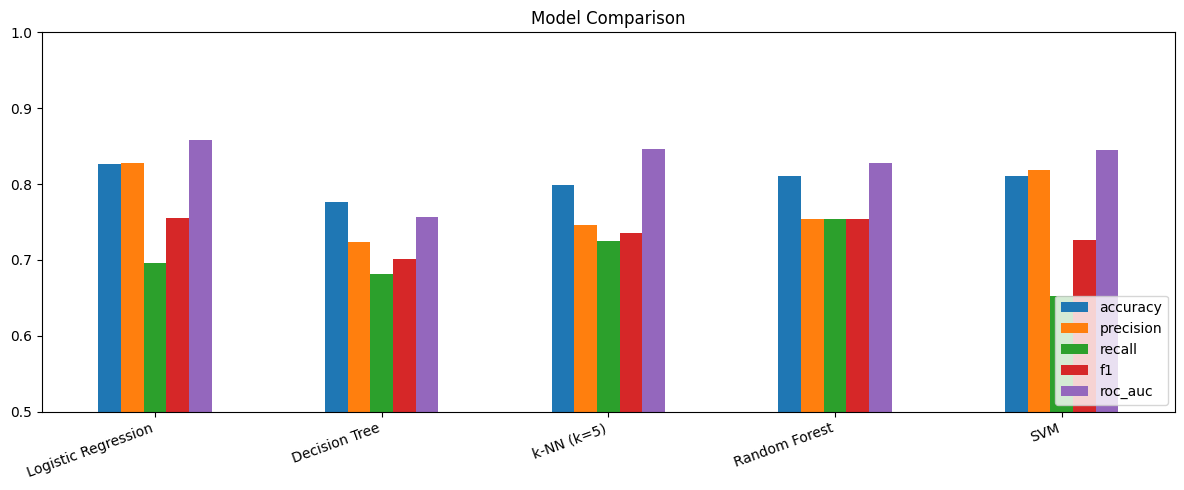

In [32]:
# Bar chart comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
compare_df = pd.DataFrame(
    {name: {m: r[m] for m in metrics} for name, r in results.items()}
).T

compare_df.plot(kind='bar', figsize=(12, 5), ylim=(0.5, 1.0))
plt.title('Model Comparison')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

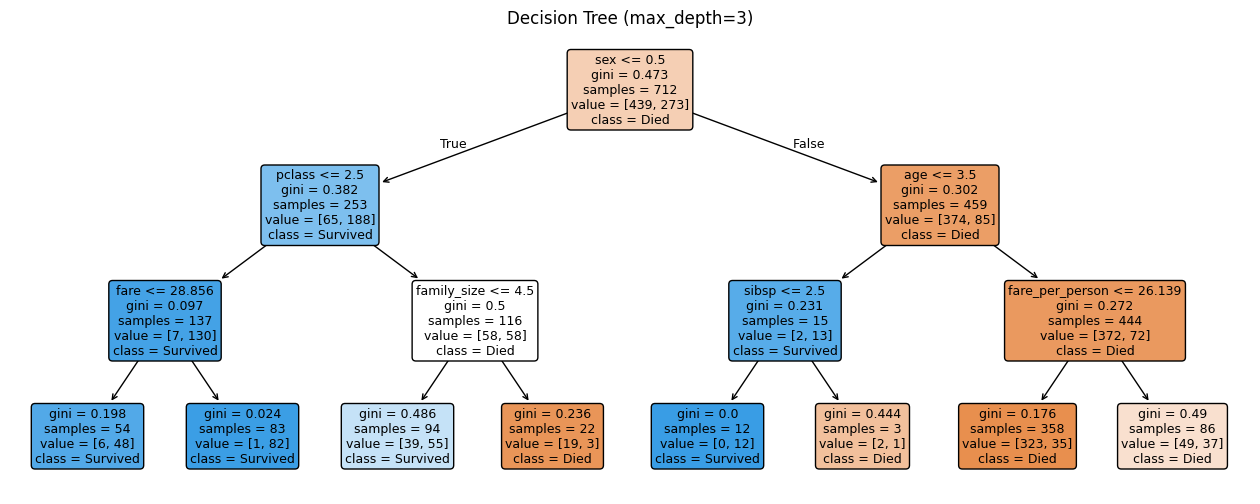

In [33]:
# Visualize Decision Tree structure
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_fe, y_train_fe)

plt.figure(figsize=(16, 6))
plot_tree(
    dt_model,
    feature_names=X_train_fe.columns.tolist(),
    class_names=['Died', 'Survived'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Decision Tree (max_depth=3)')
plt.show()

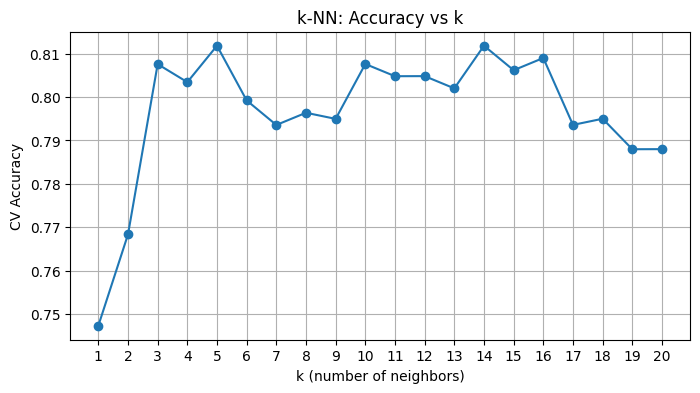

Best k: 5  |  CV Accuracy: 0.812


In [34]:
# k-NN: choosing the right k
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train_fe_scaled, y_train_fe, cv=5, scoring='accuracy').mean()
    k_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('CV Accuracy')
plt.title('k-NN: Accuracy vs k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k = k_range[k_scores.index(max(k_scores))]
print(f'Best k: {best_k}  |  CV Accuracy: {max(k_scores):.3f}')

---
## SECTION 5 — Evaluation Metrics
Deep dive into metrics for the best model.

In [35]:
# Pick best model by F1 score
best_name = max(results, key=lambda k: results[k]['f1'])
best_res = results[best_name]
print(f'Best model: {best_name}')

Best model: Logistic Regression


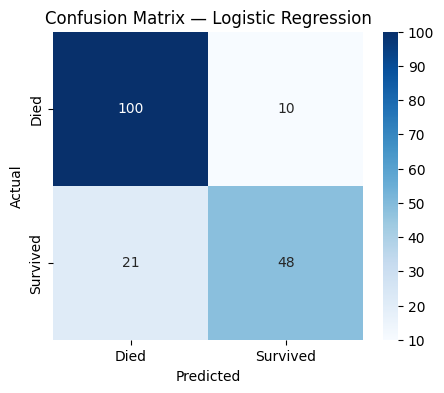

TN=100  FP=10  FN=21  TP=48
Precision = TP/(TP+FP) = 0.828  (of predicted survived, how many actually did)
Recall    = TP/(TP+FN) = 0.696  (of actual survivors, how many did we catch)


In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test_fe, best_res['y_pred'])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Died', 'Survived'],
    yticklabels=['Died', 'Survived']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Precision = TP/(TP+FP) = {tp/(tp+fp):.3f}  (of predicted survived, how many actually did)')
print(f'Recall    = TP/(TP+FN) = {tp/(tp+fn):.3f}  (of actual survivors, how many did we catch)')

In [37]:
# Full classification report
print(classification_report(y_test_fe, best_res['y_pred'], target_names=['Died', 'Survived']))

              precision    recall  f1-score   support

        Died       0.83      0.91      0.87       110
    Survived       0.83      0.70      0.76        69

    accuracy                           0.83       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179



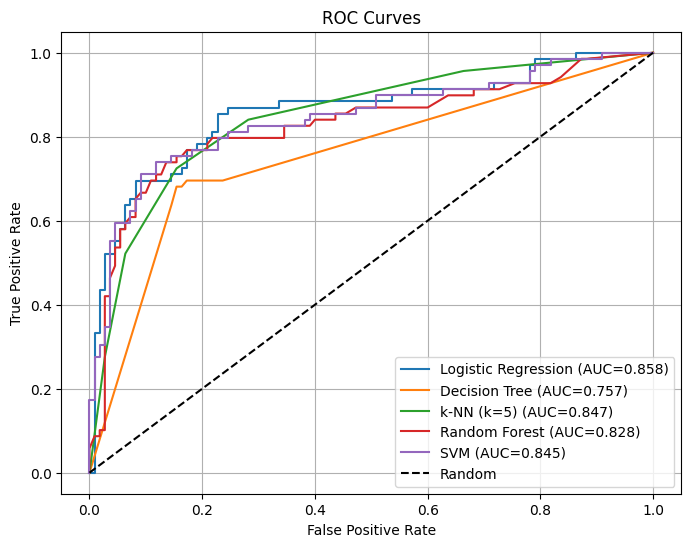

In [38]:
# ROC Curves for all models
plt.figure(figsize=(8, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test_fe, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.show()

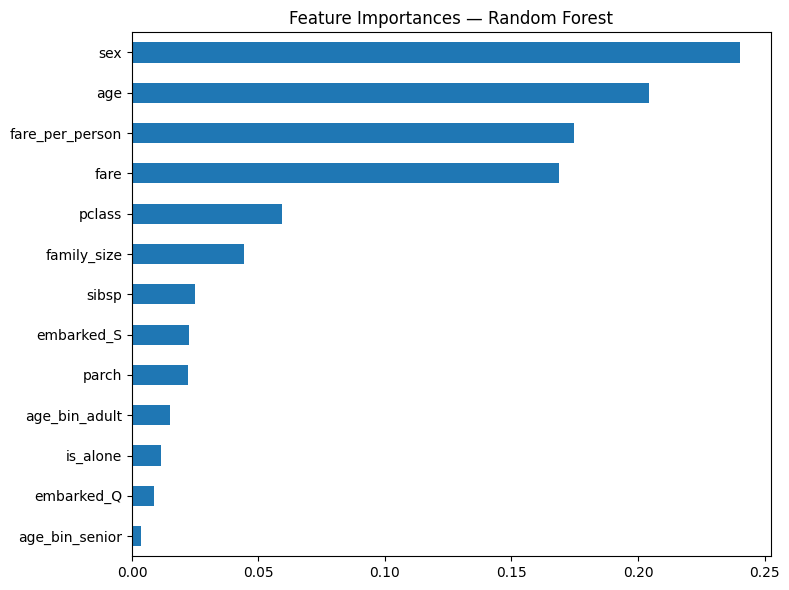

In [39]:
# Feature Importance (Random Forest)
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X_train_fe.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

---
## SECTION 6 — Hyperparameter Tuning (GridSearchCV)
Systematically search for the best model configuration.

In [40]:
# --- Tune Decision Tree ---
param_grid_dt = {
    'max_depth':        [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'criterion':        ['gini', 'entropy'],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_dt.fit(X_train_fe, y_train_fe)

print('Best DT params:', grid_dt.best_params_)
print('Best CV F1:    ', round(grid_dt.best_score_, 3))

Best DT params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10}
Best CV F1:     0.755


In [41]:
# --- Tune k-NN ---
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_knn.fit(X_train_fe_scaled, y_train_fe)

print('Best k-NN params:', grid_knn.best_params_)
print('Best CV F1:       ', round(grid_knn.best_score_, 3))

Best k-NN params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV F1:        0.745


In [42]:
# --- Evaluate tuned models on test set ---
tuned_models = {
    'Tuned Decision Tree': (grid_dt.best_estimator_, X_test_fe),
    'Tuned k-NN':          (grid_knn.best_estimator_, X_test_fe_scaled),
}

for name, (model, X_test_input) in tuned_models.items():
    y_pred = model.predict(X_test_input)
    print(f'\n{name}')
    print(f'  Accuracy : {accuracy_score(y_test_fe, y_pred):.3f}')
    print(f'  F1 Score : {f1_score(y_test_fe, y_pred):.3f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test_fe, model.predict_proba(X_test_input)[:, 1]):.3f}')


Tuned Decision Tree
  Accuracy : 0.777
  F1 Score : 0.677
  ROC-AUC  : 0.805

Tuned k-NN
  Accuracy : 0.799
  F1 Score : 0.735
  ROC-AUC  : 0.847


---
## Titanic Pipeline Quick-Reference Cheat Sheet

### Preprocessing checklist
```
1. df.info() / df.describe() / df.isnull().sum()  — understand the data
2. Fill missing: median (numeric), mode (categorical), or drop if >50% missing
3. Encode: LabelEncoder (binary), get_dummies (multi-class)
4. Scale: StandardScaler for kNN/LR/SVM; trees don't need scaling
5. train_test_split(..., stratify=y)  — keep class balance
```

### Feature engineering ideas
```
- Combine: A + B, A / B, A * B
- Bin continuous: pd.cut() or pd.qcut()
- Extract from strings: str.len(), str.contains()
- Interaction terms: col_A * col_B
```

### Model selection cheat sheet
| Model | Strength | Weakness | Needs Scaling? |
|---|---|---|---|
| Logistic Regression | Fast, interpretable | Linear boundary | Yes |
| Decision Tree | Interpretable, no scaling | Overfits | No |
| k-NN | Simple, no training | Slow at predict, sensitive to scale | Yes |
| Random Forest | Accurate, robust | Slow, less interpretable | No |
| SVM | Great for small data | Slow on large data | Yes |

### Evaluation metrics
```
Accuracy  = correct / total                       (use when classes are balanced)
Precision = TP / (TP + FP)                        (care about false alarms)
Recall    = TP / (TP + FN)                        (care about missing positives)
F1        = 2 * (precision * recall) / (precision + recall)
ROC-AUC   = ranking quality across all thresholds (best single metric)
```